In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [6]:
df = pd.read_csv("insurance.csv")
print("First 5 rows:")
print(df.head())

print("Last 5 rows:")
print(df.tail())

print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Last 5 rows:
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  


In [7]:
#Preprocessing & Encoding Categorical Features
# Binary encoding
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

# One-hot encoding for nominal column 'region'
df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

print("Processed Features:")
print(df.head())

Processed Features:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [8]:
#Train-Test Split
X = df.drop("charges", axis=1)
y = df["charges"]

# Save column order for consistent app inference
joblib.dump(list(X.columns), "feature_columns.pkl")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [9]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Model Training & Predictions
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

Mean Absolute Error (MAE): 4243.65
Root Mean Squared Error (RMSE): 5926.02
R² Score: 0.7673


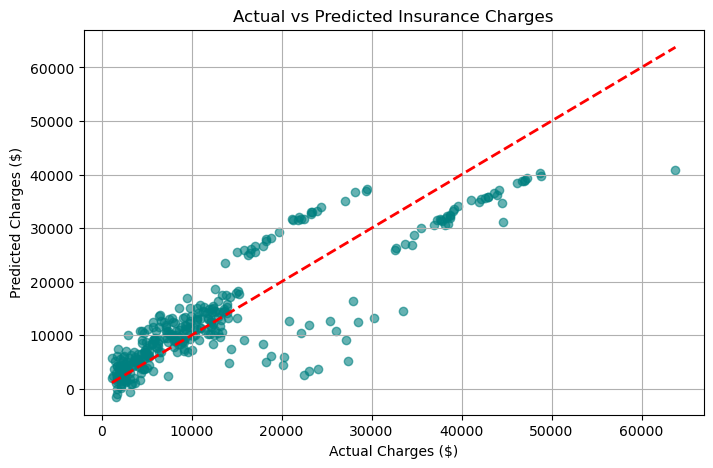

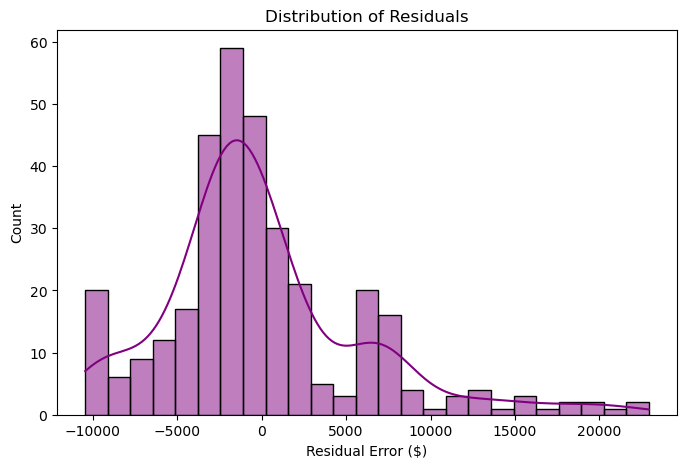

In [11]:
#Evaluation & Visualizations
# Regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot: Actual vs Predicted Charges
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Insurance Charges")
plt.grid(True)
plt.show()

# Plot: Residual Distribution
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Distribution of Residuals")
plt.xlabel("Residual Error ($)")
plt.show()

In [12]:
#Save Model Artifacts
joblib.dump(model, "insurance_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files saved: 'insurance_model.pkl', 'scaler.pkl', and 'feature_columns.pkl'")

Files saved: 'insurance_model.pkl', 'scaler.pkl', and 'feature_columns.pkl'


In [13]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load artifacts
model = joblib.load("insurance_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")

st.set_page_config(page_title="Insurance Charges Predictor", layout="centered")
st.title("Medical Insurance Cost Predictor")
st.write("Enter individual health and lifestyle metrics below to estimate annual medical charges.")

# User Input Form
with st.form("input_form"):
    col1, col2 = st.columns(2)

    with col1:
        age = st.number_input("Age", min_value=18, max_value=100, value=30, step=1)
        sex = st.selectbox("Sex", options=["female", "male"])
        bmi = st.number_input("BMI (Body Mass Index)", min_value=10.0, max_value=60.0, value=25.0, step=0.1)

    with col2:
        children = st.number_input("Number of Children", min_value=0, max_value=10, value=0, step=1)
        smoker = st.selectbox("Smoker", options=["no", "yes"])
        region = st.selectbox("Region", options=["northeast", "northwest", "southeast", "southwest"])

    submit = st.form_submit_button("Predict Charges")

if submit:
    input_dict = {
        "age": age,
        "sex": 1 if sex == "male" else 0,
        "bmi": bmi,
        "children": children,
        "smoker": 1 if smoker == "yes" else 0,
        "region_northwest": 1 if region == "northwest" else 0,
        "region_southeast": 1 if region == "southeast" else 0,
        "region_southwest": 1 if region == "southwest" else 0,
    }

    input_df = pd.DataFrame([input_dict])
    input_df = input_df[feature_columns]

    scaled_inputs = scaler.transform(input_df)
    predicted_charge = model.predict(scaled_inputs)[0]

    final_charge = max(0.0, predicted_charge)
    st.success(f"Estimated Annual Insurance Cost: **${final_charge:,.2f}**")

Writing app.py


In [ ]:
!streamlit run app.py